## **Configure Kaggle & Download Dataset**

In [1]:
import os
import zipfile

# Move kaggle.json
os.makedirs("/root/.kaggle", exist_ok=True)
!mv kaggle.json /root/.kaggle/kaggle.json
!chmod 600 /root/.kaggle/kaggle.json

# Install Kaggle CLI
!pip install -q kaggle

# Download and unzip UNSW-NB15 dataset
!kaggle datasets download -d dhoogla/unswnb15
with zipfile.ZipFile("unswnb15.zip", 'r') as zip_ref:
    zip_ref.extractall("unsw_nb15")


Dataset URL: https://www.kaggle.com/datasets/dhoogla/unswnb15
License(s): CC-BY-NC-SA-4.0
  0% 0.00/11.7M [00:00<?, ?B/s]
100% 11.7M/11.7M [00:00<00:00, 1.20GB/s]


# **Read & Concatenate Train/Test Data**

In [2]:
import pandas as pd

train_df = pd.read_parquet("/content/unsw_nb15/UNSW_NB15_training-set.parquet")
test_df = pd.read_parquet("/content/unsw_nb15/UNSW_NB15_testing-set.parquet")
df = pd.concat([train_df, test_df], ignore_index=True)
df.head()


,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,sload,...,trans_depth,response_body_len,ct_src_dport_ltm,ct_dst_sport_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,is_sm_ips_ports,attack_cat,label
0,0.121478,tcp,-,FIN,6,4,258,172,74.087486,14158.942383,...,0,0,1,1,0,0,0,0,Normal,0
1,0.649902,tcp,-,FIN,14,38,734,42014,78.473373,8395.112305,...,0,0,1,1,0,0,0,0,Normal,0
2,1.623129,tcp,-,FIN,8,16,364,13186,14.170161,1572.271851,...,0,0,1,1,0,0,0,0,Normal,0
3,1.681642,tcp,ftp,FIN,12,12,628,770,13.677108,2740.178955,...,0,0,1,1,1,1,0,0,Normal,0
4,0.449454,tcp,-,FIN,10,6,534,268,33.373825,8561.499023,...,0,0,2,1,0,0,0,0,Normal,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 257673 entries, 0 to 257672
Data columns (total 36 columns):
 #   Column             Non-Null Count   Dtype   
---  ------             --------------   -----   
 0   dur                257673 non-null  float32 
 1   proto              257673 non-null  object  
 2   service            257673 non-null  category
 3   state              257673 non-null  object  
 4   spkts              257673 non-null  int16   
 5   dpkts              257673 non-null  int16   
 6   sbytes             257673 non-null  int32   
 7   dbytes             257673 non-null  int32   
 8   rate               257673 non-null  float32 
 9   sload              257673 non-null  float32 
 10  dload              257673 non-null  float32 
 11  sloss              257673 non-null  int16   
 12  dloss              257673 non-null  int16   
 13  sinpkt             257673 non-null  float32 
 14  dinpkt             257673 non-null  float32 
 15  sjit               257673 non-null

 # **Preprocess the Dataset**

In [4]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

# Make a copy
df_clean = df.copy()



# Encode object and categorical columns
cat_cols = df_clean.select_dtypes(include=['object', 'category']).columns
label_encoders = {}

for col in cat_cols:
    le = LabelEncoder()
    df_clean[col] = le.fit_transform(df_clean[col].astype(str))
    label_encoders[col] = le

# Separate features and target
X = df_clean.drop(columns=['label'])
y = df_clean['label']


# **Exploratry data Analysis**

## **Visualize Label Distribution**

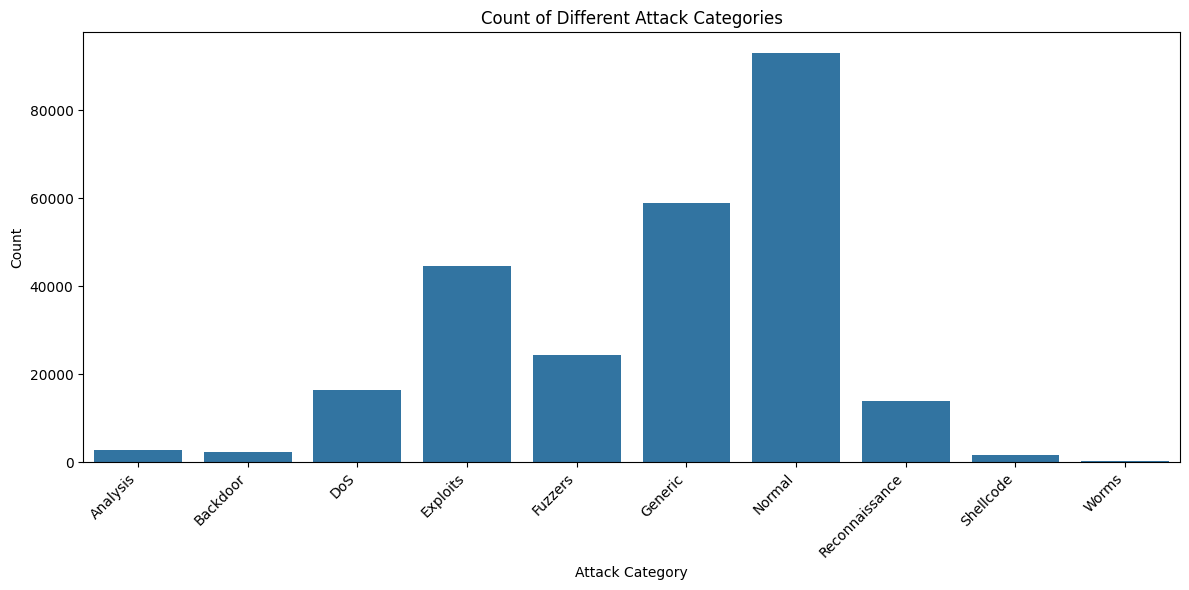

In [ ]:

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='attack_cat')
plt.title('Count of Different Attack Categories')
plt.xlabel('Attack Category')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


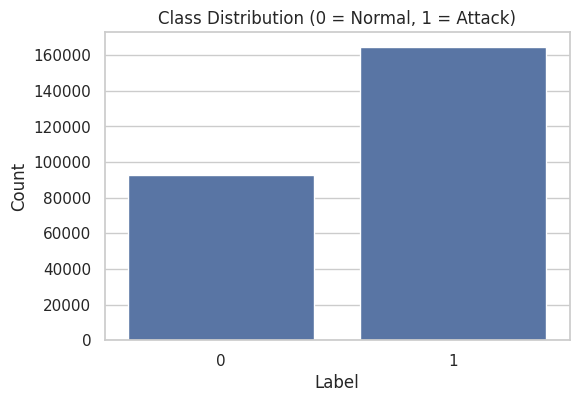

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="whitegrid")
plt.figure(figsize=(6, 4))
sns.countplot(x=y)
plt.title("Class Distribution (0 = Normal, 1 = Attack)")
plt.xlabel("Label")
plt.ylabel("Count")
plt.show()


# **Count plot to show protocol by attack Category**

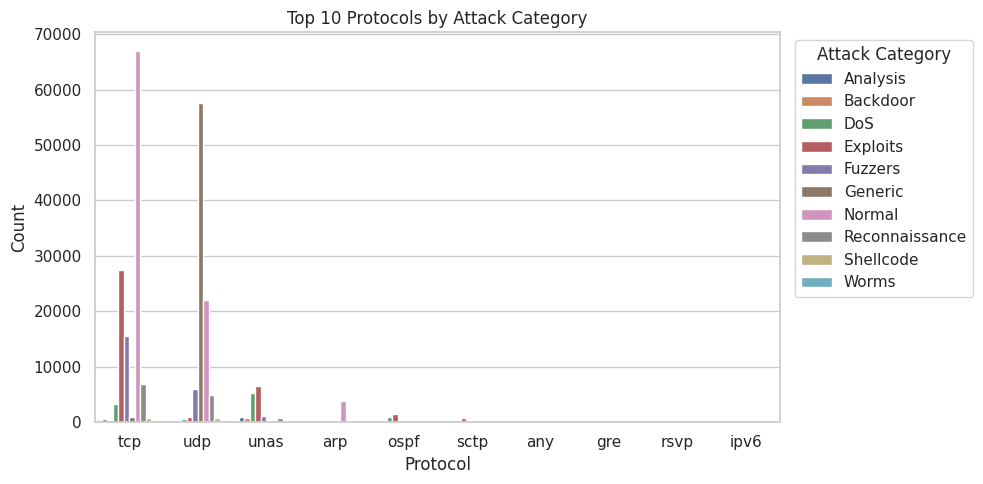

In [ ]:

# Identify top 10 most common protocols
top_protos = df['proto'].value_counts().nlargest(10).index

# Filter dataset to top protocols only
filtered_df = df[df['proto'].isin(top_protos)]

# Plot
plt.figure(figsize=(10, 5))
sns.countplot(data=filtered_df, x='proto', hue='attack_cat', order=top_protos)
plt.title("Top 10 Protocols by Attack Category")
plt.xlabel("Protocol")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left', title='Attack Category')
plt.tight_layout()
plt.show()

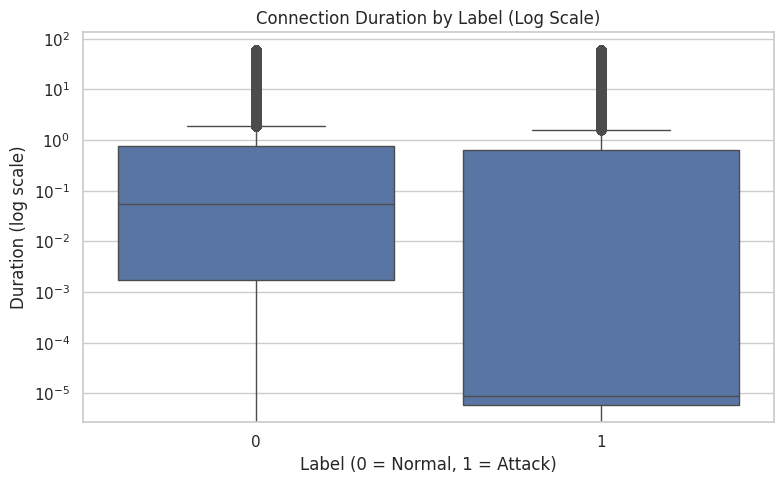

In [ ]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='label', y='dur')
plt.yscale("log")
plt.title("Connection Duration by Label (Log Scale)")
plt.xlabel("Label (0 = Normal, 1 = Attack)")
plt.ylabel("Duration (log scale)")
plt.tight_layout()
plt.show()

# **Split the Data Set**

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


📊 Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     18613
           1       1.00      1.00      1.00     32922

    accuracy                           1.00     51535
   macro avg       1.00      1.00      1.00     51535
weighted avg       1.00      1.00      1.00     51535



<Figure size 600x400 with 0 Axes>

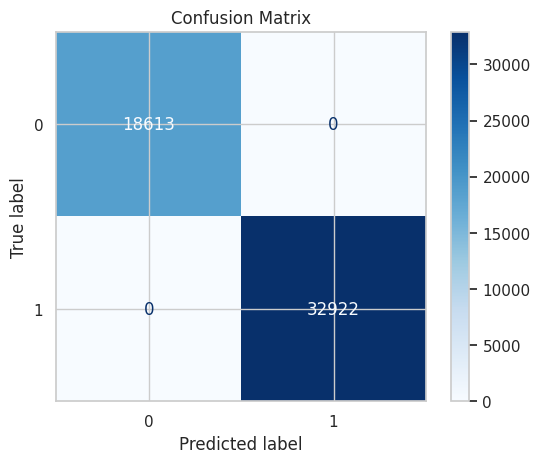

In [ ]:
print(" Classification Report:\n")
print(classification_report(y_test, y_pred))

# Confusion Matrix
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

plt.figure(figsize=(6, 4))
ConfusionMatrixDisplay.from_estimator(rf, X_test, y_test, cmap='Blues')
plt.title("Confusion Matrix")
plt.show()


# **Model Development**

## **Machine Learning Model**


--- Training and Evaluating Logistic Regression ---


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Training Time: 82.6983 seconds
Testing Time: 0.0179 seconds
Accuracy: 0.7989
Precision: 0.7855
Recall: 0.9426
F1-score: 0.8569

📊 Classification Report:

              precision    recall  f1-score   support

           0       0.84      0.54      0.66     18613
           1       0.79      0.94      0.86     32922

    accuracy                           0.80     51535
   macro avg       0.81      0.74      0.76     51535
weighted avg       0.81      0.80      0.79     51535



<Figure size 600x400 with 0 Axes>

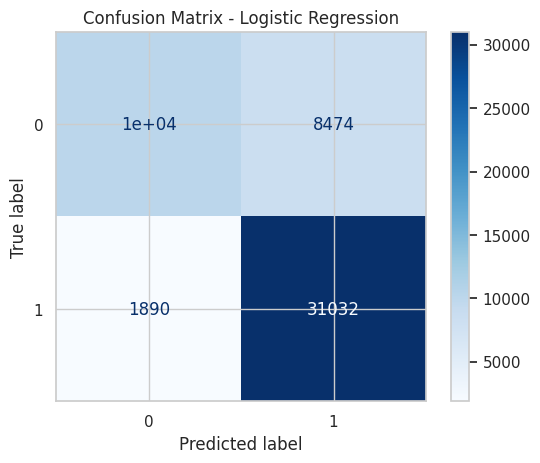

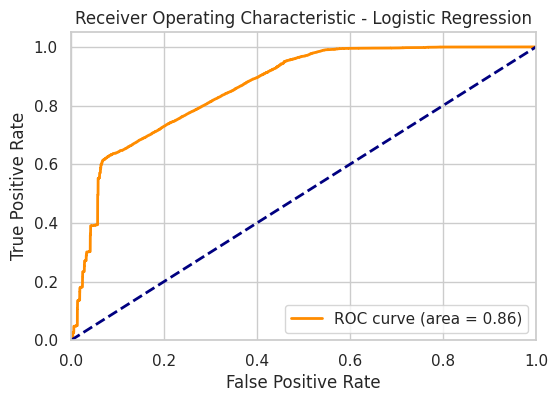


--- Training and Evaluating K-Nearest Neighbors ---
Training Time: 0.0852 seconds
Testing Time: 89.9507 seconds
Accuracy: 0.8570
Precision: 0.8720
Recall: 0.9096
F1-score: 0.8904

📊 Classification Report:

              precision    recall  f1-score   support

           0       0.83      0.76      0.79     18613
           1       0.87      0.91      0.89     32922

    accuracy                           0.86     51535
   macro avg       0.85      0.84      0.84     51535
weighted avg       0.86      0.86      0.86     51535



<Figure size 600x400 with 0 Axes>

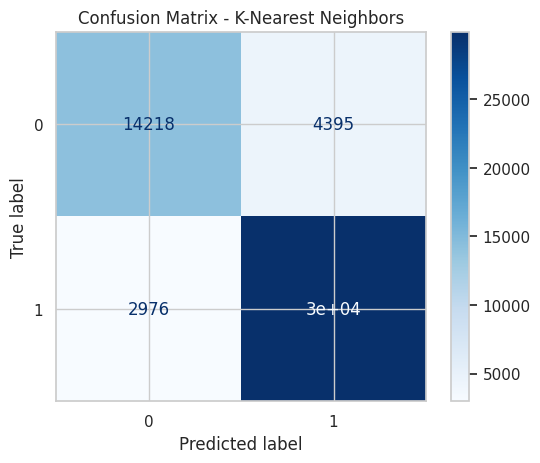

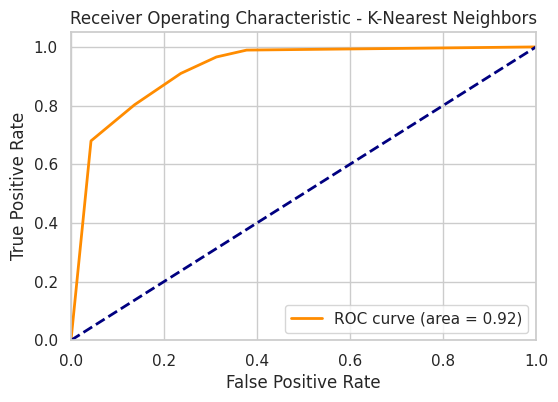


--- Training and Evaluating Gaussian Naive Bayes ---
Training Time: 0.1978 seconds
Testing Time: 0.0308 seconds
Accuracy: 0.7632
Precision: 0.7957
Recall: 0.8468
F1-score: 0.8205

📊 Classification Report:

              precision    recall  f1-score   support

           0       0.69      0.62      0.65     18613
           1       0.80      0.85      0.82     32922

    accuracy                           0.76     51535
   macro avg       0.75      0.73      0.74     51535
weighted avg       0.76      0.76      0.76     51535



<Figure size 600x400 with 0 Axes>

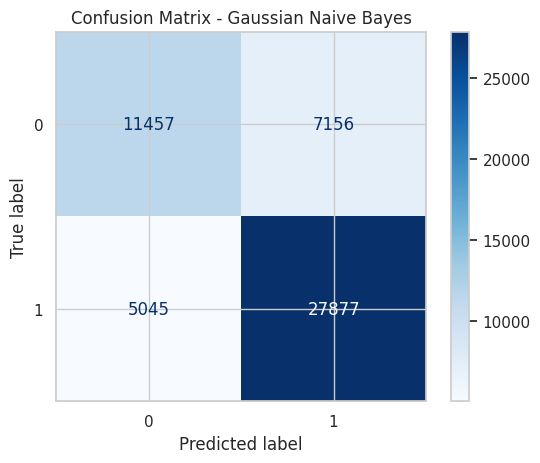

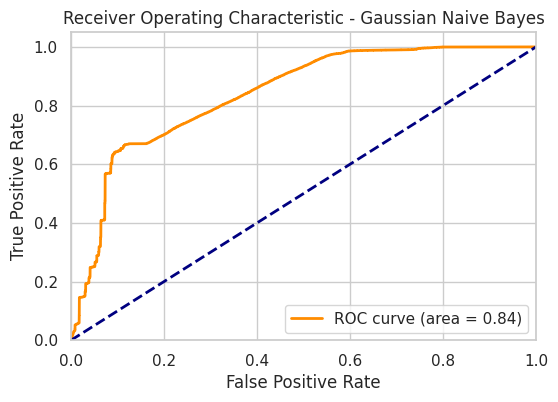


--- Training and Evaluating Neural Network ---
Training Time: 78.2580 seconds
Testing Time: 0.1182 seconds
Accuracy: 0.7772
Precision: 0.8173
Recall: 0.8389
F1-score: 0.8279

📊 Classification Report:

              precision    recall  f1-score   support

           0       0.70      0.67      0.68     18613
           1       0.82      0.84      0.83     32922

    accuracy                           0.78     51535
   macro avg       0.76      0.75      0.76     51535
weighted avg       0.78      0.78      0.78     51535



<Figure size 600x400 with 0 Axes>

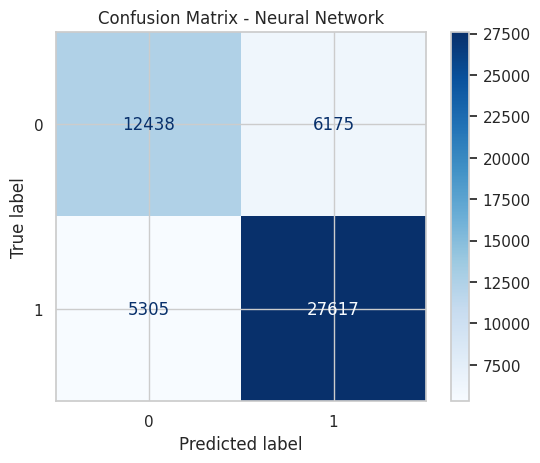

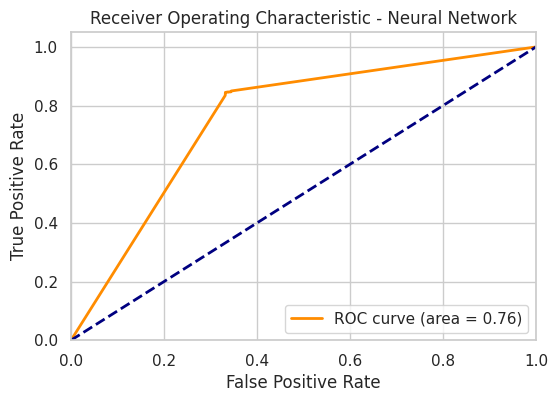


--- Model Performance Summary ---


,Training Time (s),Testing Time (s),Accuracy,Precision,Recall,F1-score,ROC AUC
Logistic Regression,82.698324,0.017883,0.798894,0.785501,0.942592,0.856906,0.861985
K-Nearest Neighbors,0.085220,89.950686,0.856971,0.872019,0.909605,0.890415,0.923445
Gaussian Naive Bayes,0.197771,0.030801,0.763248,0.795735,0.846759,0.820455,0.839086
Neural Network,78.257978,0.118231,0.777239,0.817264,0.838862,0.827922,0.755422


In [ ]:

import pandas as pd
import time
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_curve, auc, roc_auc_score, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Dictionary to store models and their names
models = {

    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),

    "K-Nearest Neighbors": KNeighborsClassifier(),
    "Gaussian Naive Bayes": GaussianNB(),
    "Neural Network": MLPClassifier(max_iter=1000, random_state=42)
}

results = {}

for name, model in models.items():
    print(f"\n--- Training and Evaluating {name} ---")

    # Training time
    start_train_time = time.time()
    model.fit(X_train, y_train)
    end_train_time = time.time()
    train_time = end_train_time - start_train_time

    # Testing time and prediction
    start_test_time = time.time()
    y_pred = model.predict(X_test)
    end_test_time = time.time()
    test_time = end_test_time - start_test_time

    # Evaluation Metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)

    results[name] = {
        "Training Time (s)": train_time,
        "Testing Time (s)": test_time,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-score": f1
    }

    print(f"Training Time: {train_time:.4f} seconds")
    print(f"Testing Time: {test_time:.4f} seconds")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-score: {f1:.4f}")

    # Classification Report
    print("\n Classification Report:\n")
    print(classification_report(y_test, y_pred, zero_division=0))

    # Confusion Matrix
    plt.figure(figsize=(6, 4))
    ConfusionMatrixDisplay.from_estimator(model, X_test, y_test, cmap='Blues')
    plt.title(f"Confusion Matrix - {name}")
    plt.show()

    # ROC Curve and AUC
    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test)[:, 1]
        fpr, tpr, thresholds = roc_curve(y_test, y_proba)
        roc_auc = auc(fpr, tpr)

        plt.figure(figsize=(6, 4))
        plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
        plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
        plt.xlim([0.0, 1.0])
        plt.ylim([0.0, 1.05])
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title(f'Receiver Operating Characteristic - {name}')
        plt.legend(loc="lower right")
        plt.show()
        results[name]["ROC AUC"] = roc_auc
    else:
        print("ROC curve not available for this model.")

# Display a summary of results
print("\n--- Model Performance Summary ---")
results_df = pd.DataFrame(results).T
results_df

## **Deep learning Modle**

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 1, 64)          │        25,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 38,049 (148.63 KB)

 Trainable params: 38,049 (148.63 KB)

...

2577/2577 ━━━━━━━━━━━━━━━━━━━━ 21s 8ms/step - accuracy: 0.9996 - f1_score: 0.7900 - loss: 0.0022 - precision: 0.9994 - recall: 1.0000 - val_accuracy: 0.9997 - val_f1_score: 0.7782 - val_loss: 0.0018 - val_precision: 0.9996 - val_recall: 1.0000
Epoch 9/50
2574/2577 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9995 - f1_score: 0.7969 - loss: 0.0027 - precision: 0.9993 - recall: 0.9999

2577/2577 ━━━━━━━━━━━━━━━━━━━━ 20s 7ms/step - accuracy: 0.9995 - f1_score: 0.7969 - loss: 0.0027 - precision: 0.9993 - recall: 0.9999 - val_accuracy: 0.9997 - val_f1_score: 0.7872 - val_loss: 0.0018 - val_precision: 0.9996 - val_recall: 1.0000
Epoch 10/50
2577/2577 ━━━━━━━━━━━━━━━━━━━━ 20s 8ms/step - accuracy: 0.9997 - f1_score: 0.7972 - loss: 0.0020 - precision: 0.9995 - recall: 1.0000 - val_accuracy: 0.9997 - val_f1_score: 0.8143 - val_loss: 0.0018 - val_precision: 0.9996 - val_recall: 0.9999
Epoch 11/50
2577/2577 ━━━━━━━━━━━━━━━━━━━━ 22s 8ms/step - accuracy: 0.9995 - f1_score: 0.8034 - loss: 0.0031 - precision: 0.9992 - recall: 0.9999 - val_accuracy: 0.9997 - val_f1_score: 0.7866 - val_loss: 0.0018 - val_precision: 0.9996 - val_recall: 1.0000
Epoch 12/50
2574/2577 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9996 - f1_score: 0.7980 - loss: 0.0022 - precision: 0.9994 - recall: 1.0000

2577/2577 ━━━━━━━━━━━━━━━━━━━━ 39s 8ms/step - accuracy: 0.9996 - f1_score: 0.7980 - loss: 0.0022 - precision: 0.9994 - recall: 1.0000 - val_accuracy: 0.9997 - val_f1_score: 0.8006 - val_loss: 0.0017 - val_precision: 0.9996 - val_recall: 1.0000
Epoch 13/50
2577/2577 ━━━━━━━━━━━━━━━━━━━━ 19s 7ms/step - accuracy: 0.9996 - f1_score: 0.8098 - loss: 0.0024 - precision: 0.9994 - recall: 1.0000 - val_accuracy: 0.9997 - val_f1_score: 0.8087 - val_loss: 0.0017 - val_precision: 0.9996 - val_recall: 1.0000
Epoch 14/50
2573/2577 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9995 - f1_score: 0.8209 - loss: 0.0027 - precision: 0.9993 - recall: 1.0000

2577/2577 ━━━━━━━━━━━━━━━━━━━━ 20s 8ms/step - accuracy: 0.9995 - f1_score: 0.8209 - loss: 0.0027 - precision: 0.9993 - recall: 1.0000 - val_accuracy: 0.9997 - val_f1_score: 0.8203 - val_loss: 0.0017 - val_precision: 0.9996 - val_recall: 1.0000
Epoch 15/50
2577/2577 ━━━━━━━━━━━━━━━━━━━━ 19s 7ms/step - accuracy: 0.9996 - f1_score: 0.8127 - loss: 0.0024 - precision: 0.9994 - recall: 0.9999 - val_accuracy: 0.9997 - val_f1_score: 0.8103 - val_loss: 0.0019 - val_precision: 0.9995 - val_recall: 1.0000
Epoch 16/50
2577/2577 ━━━━━━━━━━━━━━━━━━━━ 21s 7ms/step - accuracy: 0.9996 - f1_score: 0.8202 - loss: 0.0023 - precision: 0.9994 - recall: 1.0000 - val_accuracy: 0.9997 - val_f1_score: 0.8232 - val_loss: 0.0017 - val_precision: 0.9996 - val_recall: 1.0000
Epoch 17/50
2577/2577 ━━━━━━━━━━━━━━━━━━━━ 19s 7ms/step - accuracy: 0.9996 - f1_score: 0.8268 - loss: 0.0023 - precision: 0.9994 - recall: 1.0000 - val_accuracy: 0.9993 - val_f1_score: 0.8246 - val_loss: 0.0037 - val_precision: 0.9989 - val_rec

<Figure size 600x400 with 0 Axes>

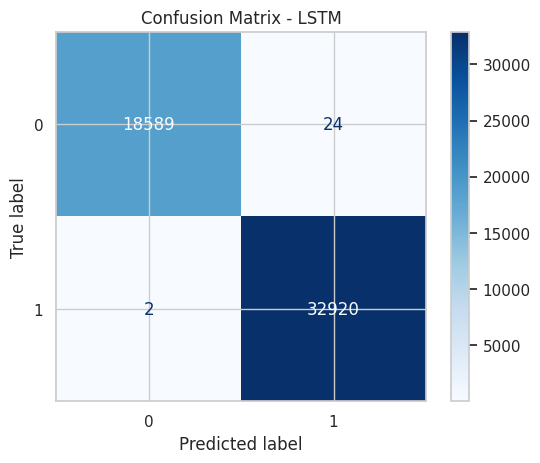


--- Plotting LSTM Training History ---


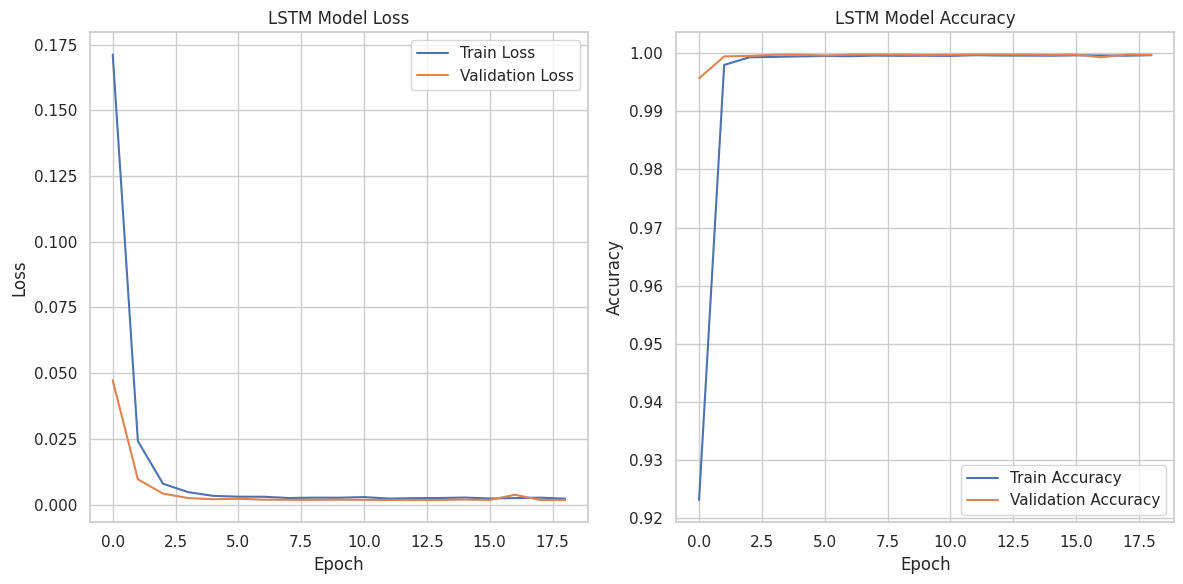

1611/1611 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step


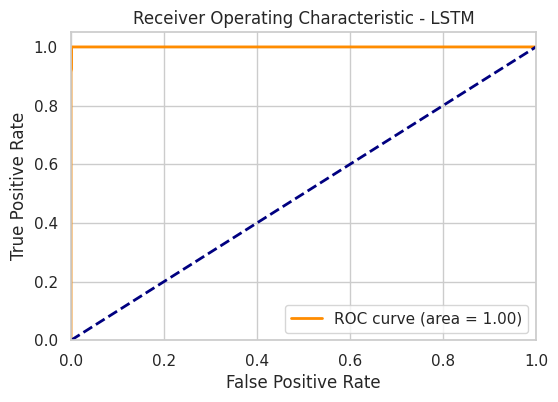


--- Updated Model Performance Summary ---


,Training Time (s),Testing Time (s),Accuracy,Precision,Recall,F1-score,ROC AUC
Logistic Regression,82.698324,0.017883,0.798894,0.785501,0.942592,0.856906,0.861985
K-Nearest Neighbors,0.085220,89.950686,0.856971,0.872019,0.909605,0.890415,0.923445
Gaussian Naive Bayes,0.197771,0.030801,0.763248,0.795735,0.846759,0.820455,0.839086
Neural Network,78.257978,0.118231,0.777239,0.817264,0.838862,0.827922,0.755422
LSTM,437.579412,5.202797,0.999496,0.999272,0.999939,0.821735,0.999897


In [ ]:

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.optimizers import Adam
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.metrics import Accuracy, Precision, Recall, F1Score
import tensorflow as tf


# Normalize features
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Reshape data for LSTM (samples, timesteps, features)
# For this dataset, each sample is a single timestep
X_train_reshaped = X_train_scaled.reshape(X_train_scaled.shape[0], 1, X_train_scaled.shape[1])
X_test_reshaped = X_test_scaled.reshape(X_test_scaled.shape[0], 1, X_test_scaled.shape[1])

# Build the LSTM model
lstm_model = Sequential()
lstm_model.add(LSTM(units=64, return_sequences=True, input_shape=(X_train_reshaped.shape[1], X_train_reshaped.shape[2])))
lstm_model.add(Dropout(0.2))
lstm_model.add(LSTM(units=32, return_sequences=False))
lstm_model.add(Dropout(0.2))
lstm_model.add(Dense(units=1, activation='sigmoid')) # Binary classification

# Compile the model
lstm_model.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy', Precision(), Recall(), F1Score()])

lstm_model.summary()

# Define callbacks for fine-tuning and saving the best model
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
model_checkpoint = ModelCheckpoint('best_lstm_model.h5', save_best_only=True, monitor='val_loss')

# Train the model
print("\n--- Training the LSTM Model ---")
start_lstm_train_time = time.time()
history = lstm_model.fit(
    X_train_reshaped, y_train,
    epochs=50,
    validation_split=0.2, # Use part of training data for validation during training
    callbacks=[early_stopping, model_checkpoint]
)
end_lstm_train_time = time.time()
lstm_train_time = end_lstm_train_time - start_lstm_train_time
print(f"LSTM Training Time: {lstm_train_time:.4f} seconds")

# Evaluate the model on the test set
print("\n--- Evaluating the LSTM Model ---")
start_lstm_test_time = time.time()
loss, accuracy, precision, recall, f1 = lstm_model.evaluate(X_test_reshaped, y_test, verbose=0)
end_lstm_test_time = time.time()
lstm_test_time = end_lstm_test_time - start_lstm_test_time
print(f"LSTM Testing Time: {lstm_test_time:.4f} seconds")

print(f"LSTM Test Loss: {loss:.4f}")
print(f"LSTM Test Accuracy: {accuracy:.4f}")
print(f"LSTM Test Precision: {precision:.4f}")
print(f"LSTM Test Recall: {recall:.4f}")
print(f"LSTM Test F1 Score: {f1:.4f}")

# Classification Report (needs thresholding for binary prediction)
y_pred_prob = lstm_model.predict(X_test_reshaped)
y_pred_lstm = (y_pred_prob > 0.5).astype("int32") # Threshold at 0.5

print("\n📊 LSTM Classification Report:\n")
print(classification_report(y_test, y_pred_lstm, zero_division=0))

# Confusion Matrix for LSTM
plt.figure(figsize=(6, 4))
cm_lstm = confusion_matrix(y_test, y_pred_lstm)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_lstm, display_labels=[0, 1])
disp.plot(cmap='Blues')
plt.title("Confusion Matrix - LSTM")
plt.show()

# Plot training history
print("\n--- Plotting LSTM Training History ---")
plt.figure(figsize=(12, 6))

# Plot Loss
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('LSTM Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend()

# Plot Accuracy
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('LSTM Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend()

plt.tight_layout()
plt.show()

# ROC Curve and AUC for LSTM
y_proba_lstm = lstm_model.predict(X_test_reshaped).ravel()
fpr_lstm, tpr_lstm, thresholds_lstm = roc_curve(y_test, y_proba_lstm)
roc_auc_lstm = auc(fpr_lstm, tpr_lstm)

plt.figure(figsize=(6, 4))
plt.plot(fpr_lstm, tpr_lstm, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc_lstm)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic - LSTM')
plt.legend(loc="lower right")
plt.show()

# Add LSTM results to the summary
results['LSTM'] = {
    "Training Time (s)": lstm_train_time,
    "Testing Time (s)": lstm_test_time,
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "F1-score": f1,
    "ROC AUC": roc_auc_lstm
}

# Display updated summary of results
print("\n--- Updated Model Performance Summary ---")
results_df_updated = pd.DataFrame(results).T
results_df_updated


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru_2 (GRU)                     │ (None, 1, 64)          │        19,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 1, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_3 (GRU)                     │ (None, 32)             │         9,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 28,833 (112.63 KB)

 Trainable params: 28,833 (112.63 KB)

...

2577/2577 ━━━━━━━━━━━━━━━━━━━━ 41s 8ms/step - accuracy: 0.9999 - f1_score: 0.8198 - loss: 5.3068e-04 - precision_2: 0.9999 - recall_2: 0.9999 - val_accuracy: 1.0000 - val_f1_score: 0.8246 - val_loss: 3.0373e-05 - val_precision_2: 1.0000 - val_recall_2: 1.0000
Epoch 7/10
2574/2577 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9998 - f1_score: 0.8188 - loss: 8.7130e-04 - precision_2: 0.9998 - recall_2: 0.9998

2577/2577 ━━━━━━━━━━━━━━━━━━━━ 41s 8ms/step - accuracy: 0.9998 - f1_score: 0.8188 - loss: 8.7069e-04 - precision_2: 0.9998 - recall_2: 0.9998 - val_accuracy: 1.0000 - val_f1_score: 0.8251 - val_loss: 1.5080e-05 - val_precision_2: 1.0000 - val_recall_2: 1.0000
Epoch 8/10
2577/2577 ━━━━━━━━━━━━━━━━━━━━ 21s 8ms/step - accuracy: 0.9998 - f1_score: 0.8282 - loss: 8.7739e-04 - precision_2: 0.9999 - recall_2: 0.9999 - val_accuracy: 1.0000 - val_f1_score: 0.8346 - val_loss: 1.7951e-05 - val_precision_2: 1.0000 - val_recall_2: 1.0000
Epoch 9/10
2575/2577 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 1.0000 - f1_score: 0.8268 - loss: 1.8091e-04 - precision_2: 1.0000 - recall_2: 1.0000

2577/2577 ━━━━━━━━━━━━━━━━━━━━ 41s 8ms/step - accuracy: 1.0000 - f1_score: 0.8268 - loss: 1.8089e-04 - precision_2: 1.0000 - recall_2: 1.0000 - val_accuracy: 1.0000 - val_f1_score: 0.8293 - val_loss: 1.0156e-05 - val_precision_2: 1.0000 - val_recall_2: 1.0000
Epoch 10/10
2573/2577 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 1.0000 - f1_score: 0.8352 - loss: 1.7552e-04 - precision_2: 1.0000 - recall_2: 1.0000

2577/2577 ━━━━━━━━━━━━━━━━━━━━ 21s 8ms/step - accuracy: 1.0000 - f1_score: 0.8352 - loss: 1.7589e-04 - precision_2: 1.0000 - recall_2: 1.0000 - val_accuracy: 1.0000 - val_f1_score: 0.8313 - val_loss: 7.1207e-06 - val_precision_2: 1.0000 - val_recall_2: 1.0000
GRU Training Time: 343.5720 seconds

--- Evaluating the GRU Model ---
GRU Testing Time: 4.9337 seconds
GRU Test Loss: 0.0000
GRU Test Accuracy: 1.0000
GRU Test Precision: 1.0000
GRU Test Recall: 1.0000
GRU Test F1 Score: 0.8329
1611/1611 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step

📊 GRU Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     18613
           1       1.00      1.00      1.00     32922

    accuracy                           1.00     51535
   macro avg       1.00      1.00      1.00     51535
weighted avg       1.00      1.00      1.00     51535



<Figure size 600x400 with 0 Axes>

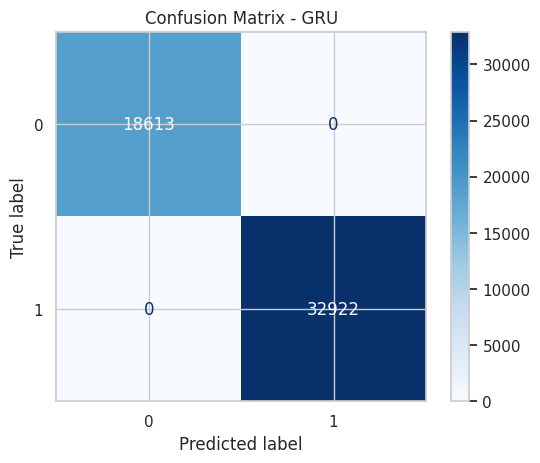


--- Plotting GRU Training History ---


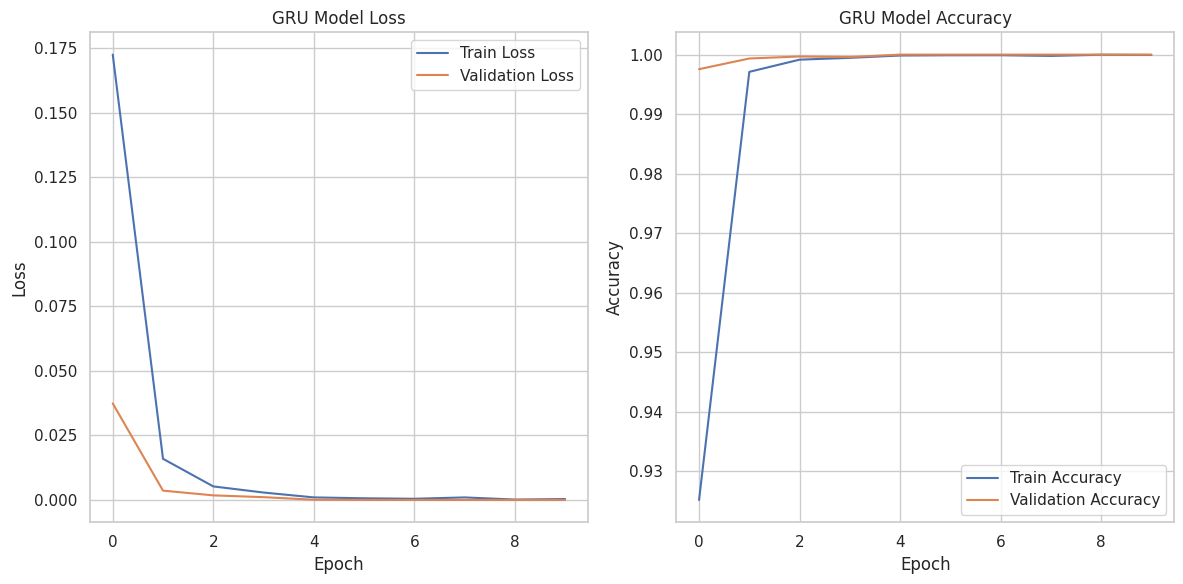

1611/1611 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step


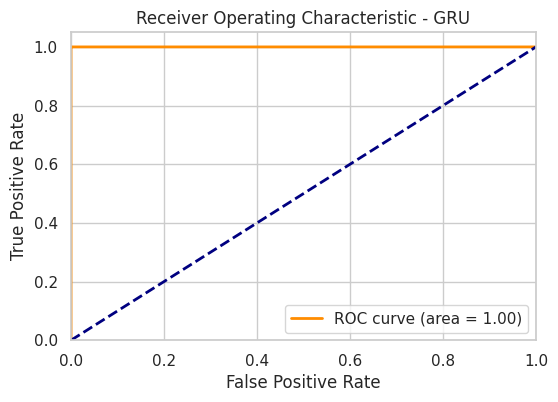


--- Updated Model Performance Summary ---


,Training Time (s),Testing Time (s),Accuracy,Precision,Recall,F1-score,ROC AUC
Logistic Regression,82.698324,0.017883,0.798894,0.785501,0.942592,0.856906,0.861985
K-Nearest Neighbors,0.085220,89.950686,0.856971,0.872019,0.909605,0.890415,0.923445
Gaussian Naive Bayes,0.197771,0.030801,0.763248,0.795735,0.846759,0.820455,0.839086
Neural Network,78.257978,0.118231,0.777239,0.817264,0.838862,0.827922,0.755422
LSTM,437.579412,5.202797,0.999496,0.999272,0.999939,0.821735,0.999897
GRU,343.572042,4.933675,1.000000,1.000000,1.000000,0.832920,1.000000


In [ ]:


import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.layers import GRU
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import Precision, Recall, F1Score

# Normalize features
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Reshape data for GRU (samples, timesteps, features)
# For this dataset, each sample is a single timestep
X_train_reshaped = X_train_scaled.reshape(X_train_scaled.shape[0], 1, X_train_scaled.shape[1])
X_test_reshaped = X_test_scaled.reshape(X_test_scaled.shape[0], 1, X_test_scaled.shape[1])

# Build the GRU model
gru_model = Sequential()
gru_model.add(GRU(units=64, return_sequences=True, input_shape=(X_train_reshaped.shape[1], X_train_reshaped.shape[2])))
gru_model.add(Dropout(0.2))
gru_model.add(GRU(units=32, return_sequences=False))
gru_model.add(Dropout(0.2))
gru_model.add(Dense(units=1, activation='sigmoid')) # Binary classification

# Compile the model
gru_model.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy', Precision(), Recall(), F1Score()])

gru_model.summary()

# Define callbacks for fine-tuning and saving the best model
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
model_checkpoint = ModelCheckpoint('best_gru_model.h5', save_best_only=True, monitor='val_loss')

# Train the model
print("\n--- Training the GRU Model ---")
start_gru_train_time = time.time()
history_gru = gru_model.fit(
    X_train_reshaped, y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.2, # Use part of training data for validation during training
    callbacks=[early_stopping, model_checkpoint]
)
end_gru_train_time = time.time()
gru_train_time = end_gru_train_time - start_gru_train_time
print(f"GRU Training Time: {gru_train_time:.4f} seconds")

# Evaluate the model on the test set
print("\n--- Evaluating the GRU Model ---")
start_gru_test_time = time.time()
loss_gru, accuracy_gru, precision_gru, recall_gru, f1_gru = gru_model.evaluate(X_test_reshaped, y_test, verbose=0)
end_gru_test_time = time.time()
gru_test_time = end_gru_test_time - start_gru_test_time
print(f"GRU Testing Time: {gru_test_time:.4f} seconds")

print(f"GRU Test Loss: {loss_gru:.4f}")
print(f"GRU Test Accuracy: {accuracy_gru:.4f}")
print(f"GRU Test Precision: {precision_gru:.4f}")
print(f"GRU Test Recall: {recall_gru:.4f}")
print(f"GRU Test F1 Score: {f1_gru:.4f}")

# Classification Report (needs thresholding for binary prediction)
y_pred_prob_gru = gru_model.predict(X_test_reshaped)
y_pred_gru = (y_pred_prob_gru > 0.5).astype("int32") # Threshold at 0.5

print("\n📊 GRU Classification Report:\n")
print(classification_report(y_test, y_pred_gru, zero_division=0))

# Confusion Matrix for GRU
plt.figure(figsize=(6, 4))
cm_gru = confusion_matrix(y_test, y_pred_gru)
disp_gru = ConfusionMatrixDisplay(confusion_matrix=cm_gru, display_labels=[0, 1])
disp_gru.plot(cmap='Blues')
plt.title("Confusion Matrix - GRU")
plt.show()

# Plot training history
print("\n--- Plotting GRU Training History ---")
plt.figure(figsize=(12, 6))

# Plot Loss
plt.subplot(1, 2, 1)
plt.plot(history_gru.history['loss'], label='Train Loss')
plt.plot(history_gru.history['val_loss'], label='Validation Loss')
plt.title('GRU Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend()

# Plot Accuracy
plt.subplot(1, 2, 2)
plt.plot(history_gru.history['accuracy'], label='Train Accuracy')
plt.plot(history_gru.history['val_accuracy'], label='Validation Accuracy')
plt.title('GRU Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend()

plt.tight_layout()
plt.show()

# ROC Curve and AUC for GRU
y_proba_gru = gru_model.predict(X_test_reshaped).ravel()
fpr_gru, tpr_gru, thresholds_gru = roc_curve(y_test, y_proba_gru)
roc_auc_gru = auc(fpr_gru, tpr_gru)

plt.figure(figsize=(6, 4))
plt.plot(fpr_gru, tpr_gru, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc_gru)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic - GRU')
plt.legend(loc="lower right")
plt.show()

# Add GRU results to the summary
results['GRU'] = {
    "Training Time (s)": gru_train_time,
    "Testing Time (s)": gru_test_time,
    "Accuracy": accuracy_gru,
    "Precision": precision_gru,
    "Recall": recall_gru,
    "F1-score": f1_gru,
    "ROC AUC": roc_auc_gru
}

# Display updated summary of results
print("\n--- Updated Model Performance Summary ---")
results_df_updated = pd.DataFrame(results).T
results_df_updated

# **Split the Data Set**

In [ ]:

# Separate features and target
X = df_clean.drop(columns=['attack_cat'])
y = df_clean['attack_cat']


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


# **Model Development**

## **Machine Learning Model**


--- Training and Evaluating Logistic Regression ---


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Training Time: 213.5555 seconds
Testing Time: 0.0243 seconds
Accuracy: 0.5518
Precision: 0.4069
Recall: 0.5518
F1-score: 0.4234

 Classification Report:

              precision    recall  f1-score   support

           0       0.00      0.00      0.00       519
           1       0.00      0.00      0.00       468
           2       0.00      0.00      0.00      3292
           3       0.40      0.04      0.08      9080
           4       0.09      0.01      0.01      4831
           5       0.51      0.98      0.67     11537
           6       0.59      0.90      0.71     18613
           7       0.00      0.00      0.00      2852
           8       0.00      0.00      0.00       309
           9       0.00      0.00      0.00        34

    accuracy                           0.55     51535
   macro avg       0.16      0.19      0.15     51535
weighted avg       0.41      0.55      0.42     51535



<Figure size 600x400 with 0 Axes>

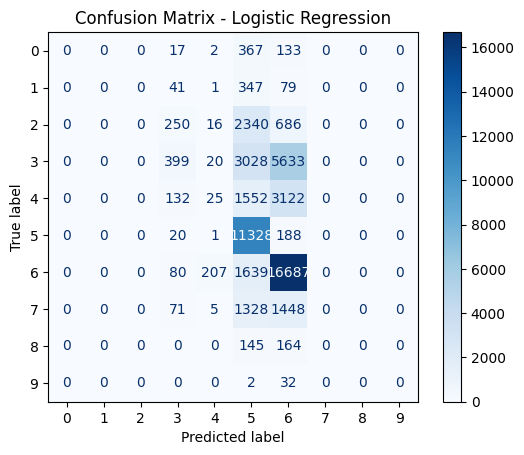

ROC curve not available for this multiclass model evaluation.

--- Training and Evaluating K-Nearest Neighbors ---
Training Time: 0.0712 seconds
Testing Time: 87.4090 seconds
Accuracy: 0.6624
Precision: 0.6713
Recall: 0.6624
F1-score: 0.6607

 Classification Report:

              precision    recall  f1-score   support

           0       0.13      0.06      0.08       519
           1       0.03      0.01      0.02       468
           2       0.29      0.33      0.31      3292
           3       0.39      0.50      0.44      9080
           4       0.35      0.30      0.32      4831
           5       1.00      0.97      0.98     11537
           6       0.79      0.79      0.79     18613
           7       0.74      0.34      0.47      2852
           8       0.35      0.11      0.17       309
           9       0.00      0.00      0.00        34

    accuracy                           0.66     51535
   macro avg       0.41      0.34      0.36     51535
weighted avg       0.67     

<Figure size 600x400 with 0 Axes>

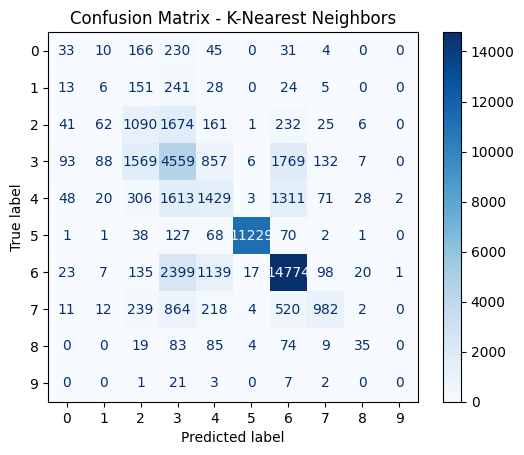

ROC curve not available for this multiclass model evaluation.

--- Training and Evaluating Gaussian Naive Bayes ---
Training Time: 0.2190 seconds
Testing Time: 0.0931 seconds
Accuracy: 0.4376
Precision: 0.5847
Recall: 0.4376
F1-score: 0.4030

 Classification Report:

              precision    recall  f1-score   support

           0       0.00      0.00      0.00       519
           1       0.00      0.00      0.00       468
           2       0.13      0.00      0.01      3292
           3       0.67      0.02      0.04      9080
           4       0.25      0.31      0.27      4831
           5       0.47      0.98      0.64     11537
           6       0.90      0.46      0.61     18613
           7       0.09      0.35      0.14      2852
           8       0.02      0.01      0.01       309
           9       0.06      0.15      0.08        34

    accuracy                           0.44     51535
   macro avg       0.26      0.23      0.18     51535
weighted avg       0.58     

<Figure size 600x400 with 0 Axes>

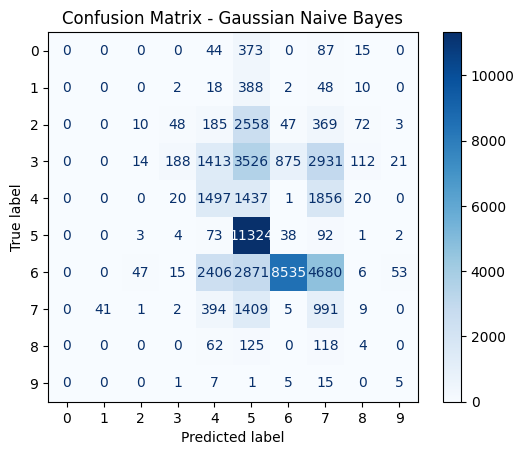

ROC curve not available for this multiclass model evaluation.

--- Training and Evaluating Neural Network ---
Training Time: 63.5321 seconds
Testing Time: 0.1177 seconds
Accuracy: 0.5536
Precision: 0.6566
Recall: 0.5536
F1-score: 0.5225

 Classification Report:

              precision    recall  f1-score   support

           0       0.00      0.00      0.00       519
           1       0.00      0.00      0.00       468
           2       0.27      0.05      0.08      3292
           3       0.31      0.93      0.47      9080
           4       0.40      0.12      0.19      4831
           5       0.81      0.97      0.89     11537
           6       0.99      0.43      0.60     18613
           7       0.12      0.02      0.04      2852
           8       0.00      0.00      0.00       309
           9       0.00      0.00      0.00        34

    accuracy                           0.55     51535
   macro avg       0.29      0.25      0.23     51535
weighted avg       0.66      0.55

<Figure size 600x400 with 0 Axes>

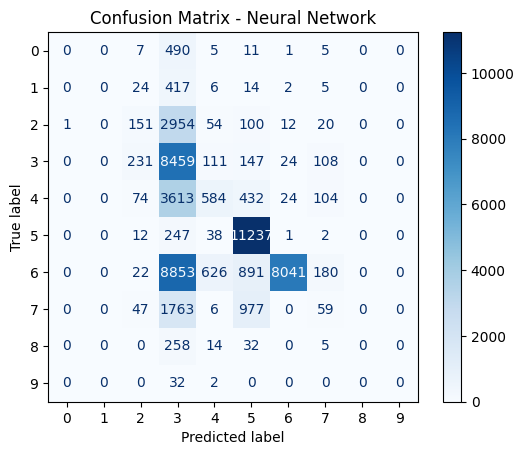

ROC curve not available for this multiclass model evaluation.

--- Model Performance Summary ---


,Training Time (s),Testing Time (s),Accuracy,Precision,Recall,F1-score
Logistic Regression,213.555496,0.024274,0.551839,0.406871,0.551839,0.423386
K-Nearest Neighbors,0.071234,87.408986,0.662404,0.671299,0.662404,0.660686
Gaussian Naive Bayes,0.218994,0.093072,0.437644,0.584651,0.437644,0.402953
Neural Network,63.532099,0.117674,0.553624,0.656627,0.553624,0.522462


In [ ]:
import pandas as pd
import time
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_curve, auc, roc_auc_score, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt

# Dictionary to store models and their names
models = {

    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),

    "K-Nearest Neighbors": KNeighborsClassifier(),
    "Gaussian Naive Bayes": GaussianNB(),
    "Neural Network": MLPClassifier(max_iter=1000, random_state=42)
}

results = {}

for name, model in models.items():
    print(f"\n--- Training and Evaluating {name} ---")

    # Training time
    start_train_time = time.time()
    model.fit(X_train, y_train)
    end_train_time = time.time()
    train_time = end_train_time - start_train_time

    # Testing time and prediction
    start_test_time = time.time()
    y_pred = model.predict(X_test)
    end_test_time = time.time()
    test_time = end_test_time - start_test_time

    # Evaluation Metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

    results[name] = {
        "Training Time (s)": train_time,
        "Testing Time (s)": test_time,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-score": f1
    }

    print(f"Training Time: {train_time:.4f} seconds")
    print(f"Testing Time: {test_time:.4f} seconds")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-score: {f1:.4f}")

    # Classification Report
    print("\n Classification Report:\n")
    print(classification_report(y_test, y_pred, zero_division=0))

    # Confusion Matrix
    plt.figure(figsize=(6, 4))
    ConfusionMatrixDisplay.from_estimator(model, X_test, y_test, cmap='Blues')
    plt.title(f"Confusion Matrix - {name}")
    plt.show()

    # ROC Curve and AUC
    # ROC Curve and AUC are typically for binary classification.
    # For multiclass, you would usually plot one-vs-rest or one-vs-one.
    # Skipping for now to fix the primary error.
    print("ROC curve not available for this multiclass model evaluation.")


# Display a summary of results
print("\n--- Model Performance Summary ---")
results_df = pd.DataFrame(results).T
results_df

## **Deep learning Modle**

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 1, 64)          │        25,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 38,346 (149.79 KB)

 Trainable params: 38,346 (149.79 KB)

...

5154/5154 ━━━━━━━━━━━━━━━━━━━━ 39s 5ms/step - accuracy: 0.8597 - loss: 0.3803 - precision_1: 0.9449 - recall_1: 0.7911 - val_accuracy: 0.8667 - val_loss: 0.3572 - val_precision_1: 0.9506 - val_recall_1: 0.8003
Epoch 41/50
5154/5154 ━━━━━━━━━━━━━━━━━━━━ 26s 5ms/step - accuracy: 0.8595 - loss: 0.3764 - precision_1: 0.9446 - recall_1: 0.7908 - val_accuracy: 0.8656 - val_loss: 0.3583 - val_precision_1: 0.9487 - val_recall_1: 0.7996
Epoch 42/50
5154/5154 ━━━━━━━━━━━━━━━━━━━━ 39s 5ms/step - accuracy: 0.8622 - loss: 0.3755 - precision_1: 0.9455 - recall_1: 0.7930 - val_accuracy: 0.8636 - val_loss: 0.3610 - val_precision_1: 0.9471 - val_recall_1: 0.7967
Epoch 43/50
5154/5154 ━━━━━━━━━━━━━━━━━━━━ 24s 5ms/step - accuracy: 0.8614 - loss: 0.3743 - precision_1: 0.9456 - recall_1: 0.7921 - val_accuracy: 0.8660 - val_loss: 0.3572 - val_precision_1: 0.9508 - val_recall_1: 0.7971
Epoch 44/50
5145/5154 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8599 - loss: 0.3760 - precision_1: 0.9444 - recall_1: 0

5154/5154 ━━━━━━━━━━━━━━━━━━━━ 43s 5ms/step - accuracy: 0.8599 - loss: 0.3760 - precision_1: 0.9444 - recall_1: 0.7917 - val_accuracy: 0.8656 - val_loss: 0.3570 - val_precision_1: 0.9499 - val_recall_1: 0.7977
Epoch 45/50
5143/5154 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8609 - loss: 0.3746 - precision_1: 0.9453 - recall_1: 0.7929

5154/5154 ━━━━━━━━━━━━━━━━━━━━ 40s 5ms/step - accuracy: 0.8609 - loss: 0.3746 - precision_1: 0.9453 - recall_1: 0.7929 - val_accuracy: 0.8653 - val_loss: 0.3554 - val_precision_1: 0.9506 - val_recall_1: 0.7969
Epoch 46/50
5154/5154 ━━━━━━━━━━━━━━━━━━━━ 25s 5ms/step - accuracy: 0.8621 - loss: 0.3720 - precision_1: 0.9465 - recall_1: 0.7940 - val_accuracy: 0.8657 - val_loss: 0.3570 - val_precision_1: 0.9473 - val_recall_1: 0.8002
Epoch 47/50
5154/5154 ━━━━━━━━━━━━━━━━━━━━ 25s 5ms/step - accuracy: 0.8622 - loss: 0.3721 - precision_1: 0.9450 - recall_1: 0.7938 - val_accuracy: 0.8655 - val_loss: 0.3568 - val_precision_1: 0.9511 - val_recall_1: 0.7970
Epoch 48/50
5154/5154 ━━━━━━━━━━━━━━━━━━━━ 26s 5ms/step - accuracy: 0.8617 - loss: 0.3718 - precision_1: 0.9456 - recall_1: 0.7938 - val_accuracy: 0.8607 - val_loss: 0.3676 - val_precision_1: 0.9467 - val_recall_1: 0.7911
Epoch 49/50
5152/5154 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8629 - loss: 0.3704 - precision_1: 0.9474 - recall_1: 0

5154/5154 ━━━━━━━━━━━━━━━━━━━━ 39s 5ms/step - accuracy: 0.8629 - loss: 0.3704 - precision_1: 0.9474 - recall_1: 0.7943 - val_accuracy: 0.8669 - val_loss: 0.3539 - val_precision_1: 0.9506 - val_recall_1: 0.7997
Epoch 50/50
5154/5154 ━━━━━━━━━━━━━━━━━━━━ 25s 5ms/step - accuracy: 0.8621 - loss: 0.3721 - precision_1: 0.9464 - recall_1: 0.7936 - val_accuracy: 0.8654 - val_loss: 0.3557 - val_precision_1: 0.9517 - val_recall_1: 0.7973
LSTM Training Time: 1623.3280 seconds

--- Evaluating the LSTM Model ---
LSTM Testing Time: 4.1638 seconds
LSTM Test Loss: 0.3585
LSTM Test Accuracy: 0.8663
LSTM Test Precision: 0.9504
LSTM Test Recall: 0.7960
1611/1611 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step

📊 LSTM Classification Report:

              precision    recall  f1-score   support

           0       0.82      0.13      0.22       519
           1       0.43      0.01      0.01       468
           2       0.78      0.01      0.02      3292
           3       0.60      0.94      0.73      9080
           4

<Figure size 1000x800 with 0 Axes>

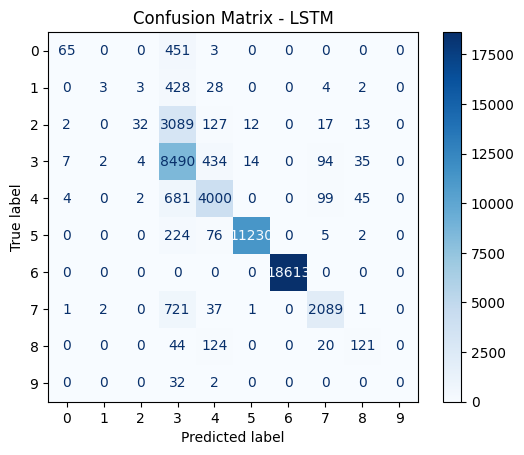


--- Plotting LSTM Training History ---


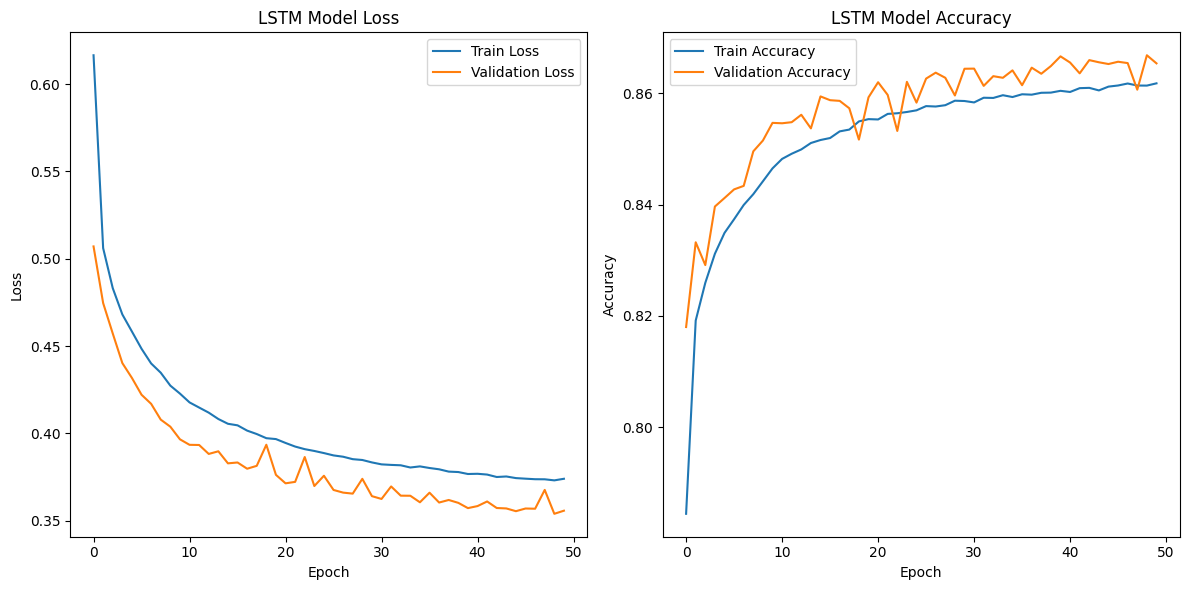


--- Plotting LSTM ROC Curve (One vs Rest) ---


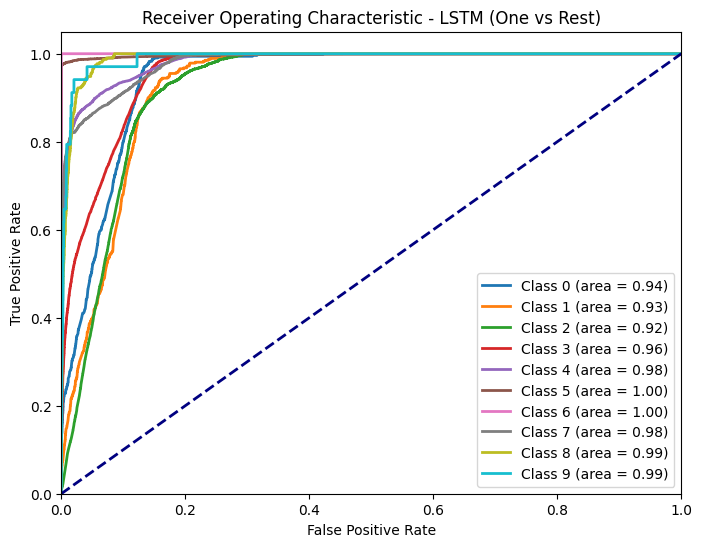


--- Updated Model Performance Summary ---
      Training Time (s)  Testing Time (s)  Accuracy  Precision    Recall  \
LSTM        1623.328042          4.163774  0.866266   0.950354  0.796022   

                       F1-score   ROC AUC  
LSTM  See Classification Report  See Plot  


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.optimizers import Adam
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.metrics import Accuracy, Precision, Recall
from tensorflow.keras.utils import to_categorical # Import for one-hot encoding
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay # Import from sklearn for detailed report and confusion matrix
import tensorflow as tf


# Normalize features
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Reshape data for LSTM (samples, timesteps, features)
# For this dataset, each sample is a single timestep
X_train_reshaped = X_train_scaled.reshape(X_train_scaled.shape[0], 1, X_train_scaled.shape[1])
X_test_reshaped = X_test_scaled.reshape(X_test_scaled.shape[0], 1, X_test_scaled.shape[1])

# One-hot encode the target variable for multiclass classification
num_classes = len(y.unique()) # Get the number of unique classes
y_train_encoded = to_categorical(y_train, num_classes=num_classes)
y_test_encoded = to_categorical(y_test, num_classes=num_classes)


# Build the LSTM model
lstm_model = Sequential()
lstm_model.add(LSTM(units=64, return_sequences=True, input_shape=(X_train_reshaped.shape[1], X_train_reshaped.shape[2])))
lstm_model.add(Dropout(0.2))
lstm_model.add(LSTM(units=32, return_sequences=False))
lstm_model.add(Dropout(0.2))
lstm_model.add(Dense(units=num_classes, activation='softmax')) # Changed units to num_classes and activation to softmax

# Compile the model
lstm_model.compile(optimizer=Adam(learning_rate=0.001), loss='categorical_crossentropy', metrics=['accuracy', Precision(), Recall()]) # Changed loss to categorical_crossentropy and removed Keras F1Score


lstm_model.summary()

# Define callbacks for fine-tuning and saving the best model
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
model_checkpoint = ModelCheckpoint('best_lstm_model.h5', save_best_only=True, monitor='val_loss')

# Train the model
print("\n--- Training the LSTM Model ---")
start_lstm_train_time = time.time()
history = lstm_model.fit(
    X_train_reshaped, y_train_encoded, # Use one-hot encoded target
    epochs=50,
    validation_split=0.2, # Use part of training data for validation during training
    # callbacks=[early_stopping, model_checkpoint] # Added callbacks
)
end_lstm_train_time = time.time()
lstm_train_time = end_lstm_train_time - start_lstm_train_time
print(f"LSTM Training Time: {lstm_train_time:.4f} seconds")

# Evaluate the model on the test set
print("\n--- Evaluating the LSTM Model ---")
start_lstm_test_time = time.time()
loss, accuracy, precision, recall = lstm_model.evaluate(X_test_reshaped, y_test_encoded, verbose=0) # Evaluate with one-hot encoded target
end_lstm_test_time = time.time()
lstm_test_time = end_lstm_test_time - start_lstm_test_time
print(f"LSTM Testing Time: {lstm_test_time:.4f} seconds")

print(f"LSTM Test Loss: {loss:.4f}")
print(f"LSTM Test Accuracy: {accuracy:.4f}")
print(f"LSTM Test Precision: {precision:.4f}")
print(f"LSTM Test Recall: {recall:.4f}")


# Classification Report (needs thresholding for binary prediction)
y_pred_prob = lstm_model.predict(X_test_reshaped)
y_pred_lstm = np.argmax(y_pred_prob, axis=1) # Get the predicted class index

print("\n LSTM Classification Report:\n")
print(classification_report(y_test, y_pred_lstm, zero_division=0)) # Use original y_test for sklearn classification report

# Confusion Matrix for LSTM
plt.figure(figsize=(10, 8)) # Increased figure size
cm_lstm = confusion_matrix(y_test, y_pred_lstm)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_lstm) # Removed display_labels as it can be inferred
disp.plot(cmap='Blues')
plt.title("Confusion Matrix - LSTM")
plt.show()

# Plot training history
print("\n--- Plotting LSTM Training History ---")
plt.figure(figsize=(12, 6))

# Plot Loss
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('LSTM Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend()

# Plot Accuracy
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('LSTM Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend()

plt.tight_layout()
plt.show()

# ROC Curve and AUC (Multiclass - One vs Rest)
# Note: ROC AUC for multiclass is typically done in a one-vs-rest or one-vs-one manner.
# Here's a simplified one-vs-rest example:
print("\n--- Plotting LSTM ROC Curve (One vs Rest) ---")
plt.figure(figsize=(8, 6))
for i in range(num_classes):
    fpr, tpr, thresholds = roc_curve(y_test_encoded[:, i], y_pred_prob[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f'Class {i} (area = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic - LSTM (One vs Rest)')
plt.legend(loc="lower right")
plt.show()


# Add LSTM results to the summary
# Note: F1-score from evaluate is removed as it's not directly available for multiclass in Keras metrics.
# We'll rely on the classification_report for detailed F1-scores per class.
results['LSTM'] = {
    "Training Time (s)": lstm_train_time,
    "Testing Time (s)": lstm_test_time,
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "F1-score": "See Classification Report", # Indicate that F1-score is in the report
    "ROC AUC": "See Plot" # Indicate that ROC AUC is in the plot
}

# Display updated summary of results
print("\n--- Updated Model Performance Summary ---")
# Ensure 'GRU' key exists before accessing it, if the GRU cell hasn't been run yet
if 'GRU' in results:
    results_df_updated = pd.DataFrame(results).T
else:
    # Create a DataFrame with only the 'LSTM' results if GRU hasn't been added yet
    results_df_updated = pd.DataFrame([results['LSTM']], index=['LSTM'])

print(results_df_updated)

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru_2 (GRU)                     │ (None, 1, 64)          │        19,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 1, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_3 (GRU)                     │ (None, 32)             │         9,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,130 (113.79 KB)

 Trainable params: 29,130 (113.79 KB)

 Non-trainable params: 0 (0.00 B)


--- Training the GRU Model ---
Epoch 1/50
2577/2577 ━━━━━━━━━━━━━━━━━━━━ 20s 6ms/step - accuracy: 0.7137 - loss: 0.8581 - precision_3: 0.9101 - recall_3: 0.5718 - val_accuracy: 0.8040 - val_loss: 0.5262 - val_precision_3: 0.9380 - val_recall_3: 0.7182
Epoch 2/50
2577/2577 ━━━━━━━━━━━━━━━━━━━━ 19s 5ms/step - accuracy: 0.8046 - loss: 0.5326 - precision_3: 0.9289 - recall_3: 0.7169 - val_accuracy: 0.8279 - val_loss: 0.4858 - val_precision_3: 0.9397 - val_recall_3: 0.7280
Epoch 3/50
2577/2577 ━━━━━━━━━━━━━━━━━━━━ 15s 6ms/step - accuracy: 0.8216 - loss: 0.4976 - precision_3: 0.9279 - recall_3: 0.7313 - val_accuracy: 0.8283 - val_loss: 0.4666 - val_precision_3: 0.9293 - val_recall_3: 0.7404
Epoch 4/50
2577/2577 ━━━━━━━━━━━━━━━━━━━━ 19s 5ms/step - accuracy: 0.8271 - loss: 0.4838 - precision_3: 0.9301 - recall_3: 0.7382 - val_accuracy: 0.8381 - val_loss: 0.4518 - val_precision_3: 0.9415 - val_recall_3: 0.7447
Epoch 5/50
2577/2577 ━━━━━━━━━━━━━━━━━━━━ 14s 5ms/step - accuracy: 0.8304 - loss: 0.

<Figure size 1000x800 with 0 Axes>

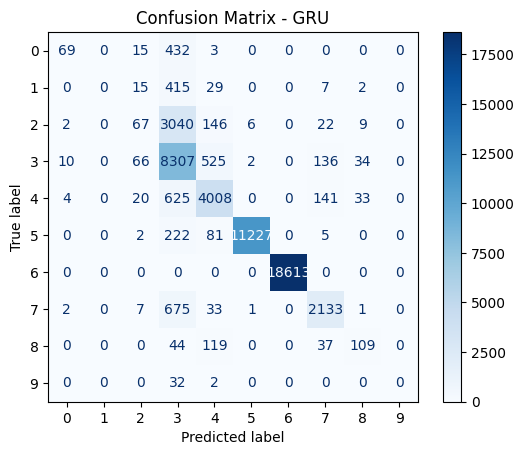


--- Plotting GRU Training History ---


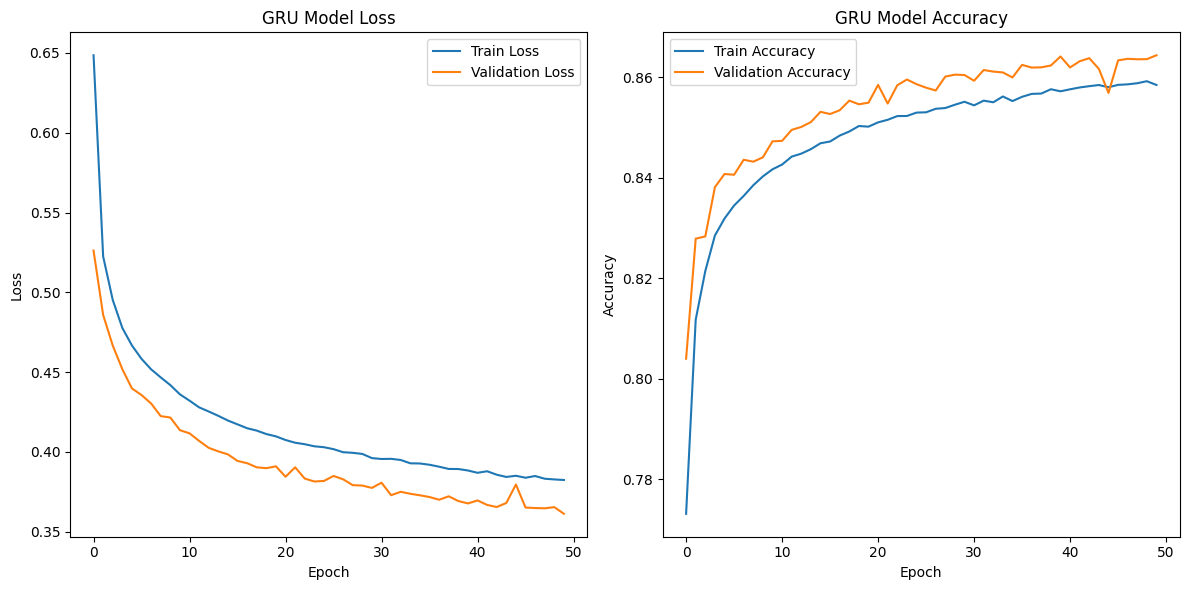


--- Plotting GRU ROC Curve (One vs Rest) ---


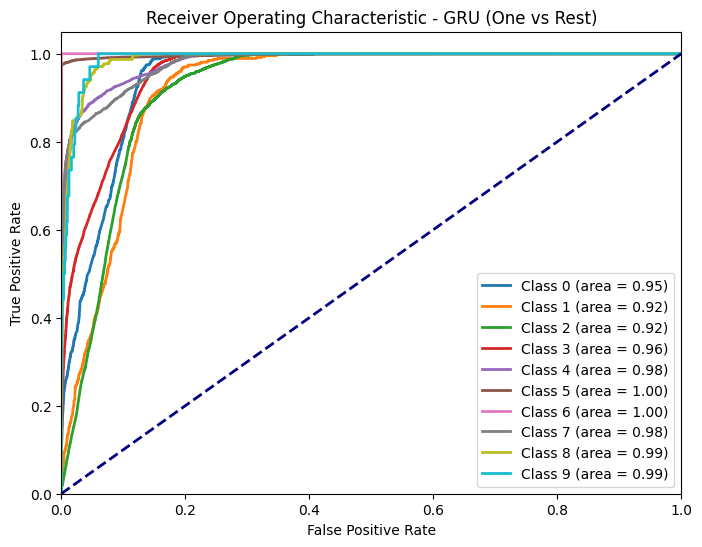


--- Updated Model Performance Summary ---
                     Training Time (s) Testing Time (s)  Accuracy Precision  \
Logistic Regression         213.555496         0.024274  0.551839  0.406871   
K-Nearest Neighbors           0.071234        87.408986  0.662404  0.671299   
Gaussian Naive Bayes          0.218994         0.093072  0.437644  0.584651   
Neural Network               63.532099         0.117674  0.553624  0.656627   
LSTM                       1623.328042         4.163774  0.866266  0.950354   
GRU                         862.847081         5.188131  0.864131  0.947248   

                        Recall                   F1-score   ROC AUC  
Logistic Regression   0.551839                   0.423386       NaN  
K-Nearest Neighbors   0.662404                   0.660686       NaN  
Gaussian Naive Bayes  0.437644                   0.402953       NaN  
Neural Network        0.553624                   0.522462       NaN  
LSTM                  0.796022  See Classification Re

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.layers import GRU, Dense, Dropout # Added Dense and Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import Precision, Recall # Removed F1Score
from tensorflow.keras.utils import to_categorical # Import for one-hot encoding
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc # Import from sklearn for detailed report, confusion matrix, and ROC AUC
import time # Import time

# Normalize features
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Reshape data for GRU (samples, timesteps, features)
# For this dataset, each sample is a single timestep
X_train_reshaped = X_train_scaled.reshape(X_train_scaled.shape[0], 1, X_train_scaled.shape[1])
X_test_reshaped = X_test_scaled.reshape(X_test_scaled.shape[0], 1, X_test_scaled.shape[1])

# One-hot encode the target variable for multiclass classification
num_classes = len(y.unique()) # Get the number of unique classes
y_train_encoded = to_categorical(y_train, num_classes=num_classes)
y_test_encoded = to_categorical(y_test, num_classes=num_classes)


# Build the GRU model
gru_model = Sequential()
gru_model.add(GRU(units=64, return_sequences=True, input_shape=(X_train_reshaped.shape[1], X_train_reshaped.shape[2])))
gru_model.add(Dropout(0.2))
gru_model.add(GRU(units=32, return_sequences=False))
gru_model.add(Dropout(0.2))
gru_model.add(Dense(units=num_classes, activation='softmax')) # Changed units to num_classes and activation to softmax

# Compile the model
gru_model.compile(optimizer=Adam(learning_rate=0.001), loss='categorical_crossentropy', metrics=['accuracy', Precision(), Recall()]) # Changed loss to categorical_crossentropy and removed Keras F1Score

gru_model.summary()

# Define callbacks for fine-tuning and saving the best model
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
model_checkpoint = ModelCheckpoint('best_gru_model.h5', save_best_only=True, monitor='val_loss')

# Train the model
print("\n--- Training the GRU Model ---")
start_gru_train_time = time.time()
history_gru = gru_model.fit(
    X_train_reshaped, y_train_encoded, # Use one-hot encoded target
    epochs=50,
    batch_size=64,
    validation_split=0.2, # Use part of training data for validation during training
    # callbacks=[early_stopping, model_checkpoint]
)
end_gru_train_time = time.time()
gru_train_time = end_gru_train_time - start_gru_train_time
print(f"GRU Training Time: {gru_train_time:.4f} seconds")

# Evaluate the model on the test set
print("\n--- Evaluating the GRU Model ---")
start_gru_test_time = time.time()
loss_gru, accuracy_gru, precision_gru, recall_gru = gru_model.evaluate(X_test_reshaped, y_test_encoded, verbose=0) # Evaluate with one-hot encoded target
end_gru_test_time = time.time()
gru_test_time = end_gru_test_time - start_gru_test_time
print(f"GRU Testing Time: {gru_test_time:.4f} seconds")

print(f"GRU Test Loss: {loss_gru:.4f}")
print(f"GRU Test Accuracy: {accuracy_gru:.4f}")
print(f"GRU Test Precision: {precision_gru:.4f}")
print(f"GRU Test Recall: {recall_gru:.4f}")


# Classification Report (needs thresholding for binary prediction)
y_pred_prob_gru = gru_model.predict(X_test_reshaped)
y_pred_gru = np.argmax(y_pred_prob_gru, axis=1) # Get the predicted class index

print("\n GRU Classification Report:\n")
print(classification_report(y_test, y_pred_gru, zero_division=0)) # Use original y_test for sklearn classification report

# Confusion Matrix for GRU
plt.figure(figsize=(10, 8)) # Increased figure size
cm_gru = confusion_matrix(y_test, y_pred_gru)
disp_gru = ConfusionMatrixDisplay(confusion_matrix=cm_gru) # Removed display_labels
disp_gru.plot(cmap='Blues')
plt.title("Confusion Matrix - GRU")
plt.show()

# Plot training history
print("\n--- Plotting GRU Training History ---")
plt.figure(figsize=(12, 6))

# Plot Loss
plt.subplot(1, 2, 1)
plt.plot(history_gru.history['loss'], label='Train Loss')
plt.plot(history_gru.history['val_loss'], label='Validation Loss')
plt.title('GRU Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend()

# Plot Accuracy
plt.subplot(1, 2, 2)
plt.plot(history_gru.history['accuracy'], label='Train Accuracy')
plt.plot(history_gru.history['val_accuracy'], label='Validation Accuracy')
plt.title('GRU Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend()

plt.tight_layout()
plt.show()

# ROC Curve and AUC (Multiclass - One vs Rest)
print("\n--- Plotting GRU ROC Curve (One vs Rest) ---")
plt.figure(figsize=(8, 6))
for i in range(num_classes):
    fpr_gru, tpr_gru, thresholds_gru = roc_curve(y_test_encoded[:, i], y_pred_prob_gru[:, i])
    roc_auc_gru = auc(fpr_gru, tpr_gru)
    plt.plot(fpr_gru, tpr_gru, lw=2, label=f'Class {i} (area = {roc_auc_gru:.2f})')

plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic - GRU (One vs Rest)')
plt.legend(loc="lower right")
plt.show()

# Add GRU results to the summary
# Ensure 'results' dictionary exists and contains previous results
if 'results' not in locals():
    results = {}

results['GRU'] = {
    "Training Time (s)": gru_train_time,
    "Testing Time (s)": gru_test_time,
    "Accuracy": accuracy_gru,
    "Precision": precision_gru,
    "Recall": recall_gru,
     "F1-score": "See Classification Report", # Indicate that F1-score is in the report
    "ROC AUC": "See Plot" # Indicate that ROC AUC is in the plot
}

# Display updated summary of results
print("\n--- Updated Model Performance Summary ---")
results_df_updated = pd.DataFrame(results).T
print(results_df_updated)